In [1]:
# ============================================================================
# CELL 1: Import Libraries and Setup
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import cophenet
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# ============================================================================
# CELL 2: Load and Explore Injury Data
# ============================================================================

df = pd.read_csv('InjuryRecord.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (105, 9)
Columns: ['PlayerKey', 'GameID', 'PlayKey', 'BodyPart', 'Surface', 'DM_M1', 'DM_M7', 'DM_M28', 'DM_M42']


,PlayerKey,GameID,PlayKey,BodyPart,Surface,DM_M1,DM_M7,DM_M28,DM_M42
0,39873,39873-4,39873-4-32,Knee,Synthetic,1,1,1,1
1,46074,46074-7,46074-7-26,Knee,Natural,1,1,0,0
2,36557,36557-1,36557-1-70,Ankle,Synthetic,1,1,1,1
3,46646,46646-3,46646-3-30,Ankle,Natural,1,0,0,0
4,43532,43532-5,43532-5-69,Ankle,Synthetic,1,1,1,1


In [3]:
# ============================================================================
# CELL 3: Data Preprocessing and Feature Engineering
# ============================================================================

# Check for missing values and data types
print("Missing values:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)

# Create binary injury severity features
df['severe_injury'] = ((df['DM_M28'] > 0) | (df['DM_M42'] > 0)).astype(int)
df['quick_recovery'] = ((df['DM_M1'] == 0) & (df['DM_M7'] == 0)).astype(int)
df['total_recovery_days'] = df['DM_M1'] + df['DM_M7'] + df['DM_M28'] + df['DM_M42']

# Surface type grouping
surface_mapping = {
    'Natural': 'Natural_Grass',
    'Synthetic': 'Artificial_Turf'
}
df['surface_type'] = df['Surface'].map(surface_mapping).fillna(df['Surface'])

print(f"Severe injuries: {df['severe_injury'].sum()} ({df['severe_injury'].mean():.1%})")
print(f"Quick recoveries: {df['quick_recovery'].sum()} ({df['quick_recovery'].mean():.1%})")

Missing values:
PlayerKey     0
GameID        0
PlayKey      28
BodyPart      0
Surface       0
DM_M1         0
DM_M7         0
DM_M28        0
DM_M42        0
dtype: int64

Data types:
PlayerKey     int64
GameID       object
PlayKey      object
BodyPart     object
Surface      object
DM_M1         int64
DM_M7         int64
DM_M28        int64
DM_M42        int64
dtype: object
Severe injuries: 37 (35.2%)
Quick recoveries: 0 (0.0%)


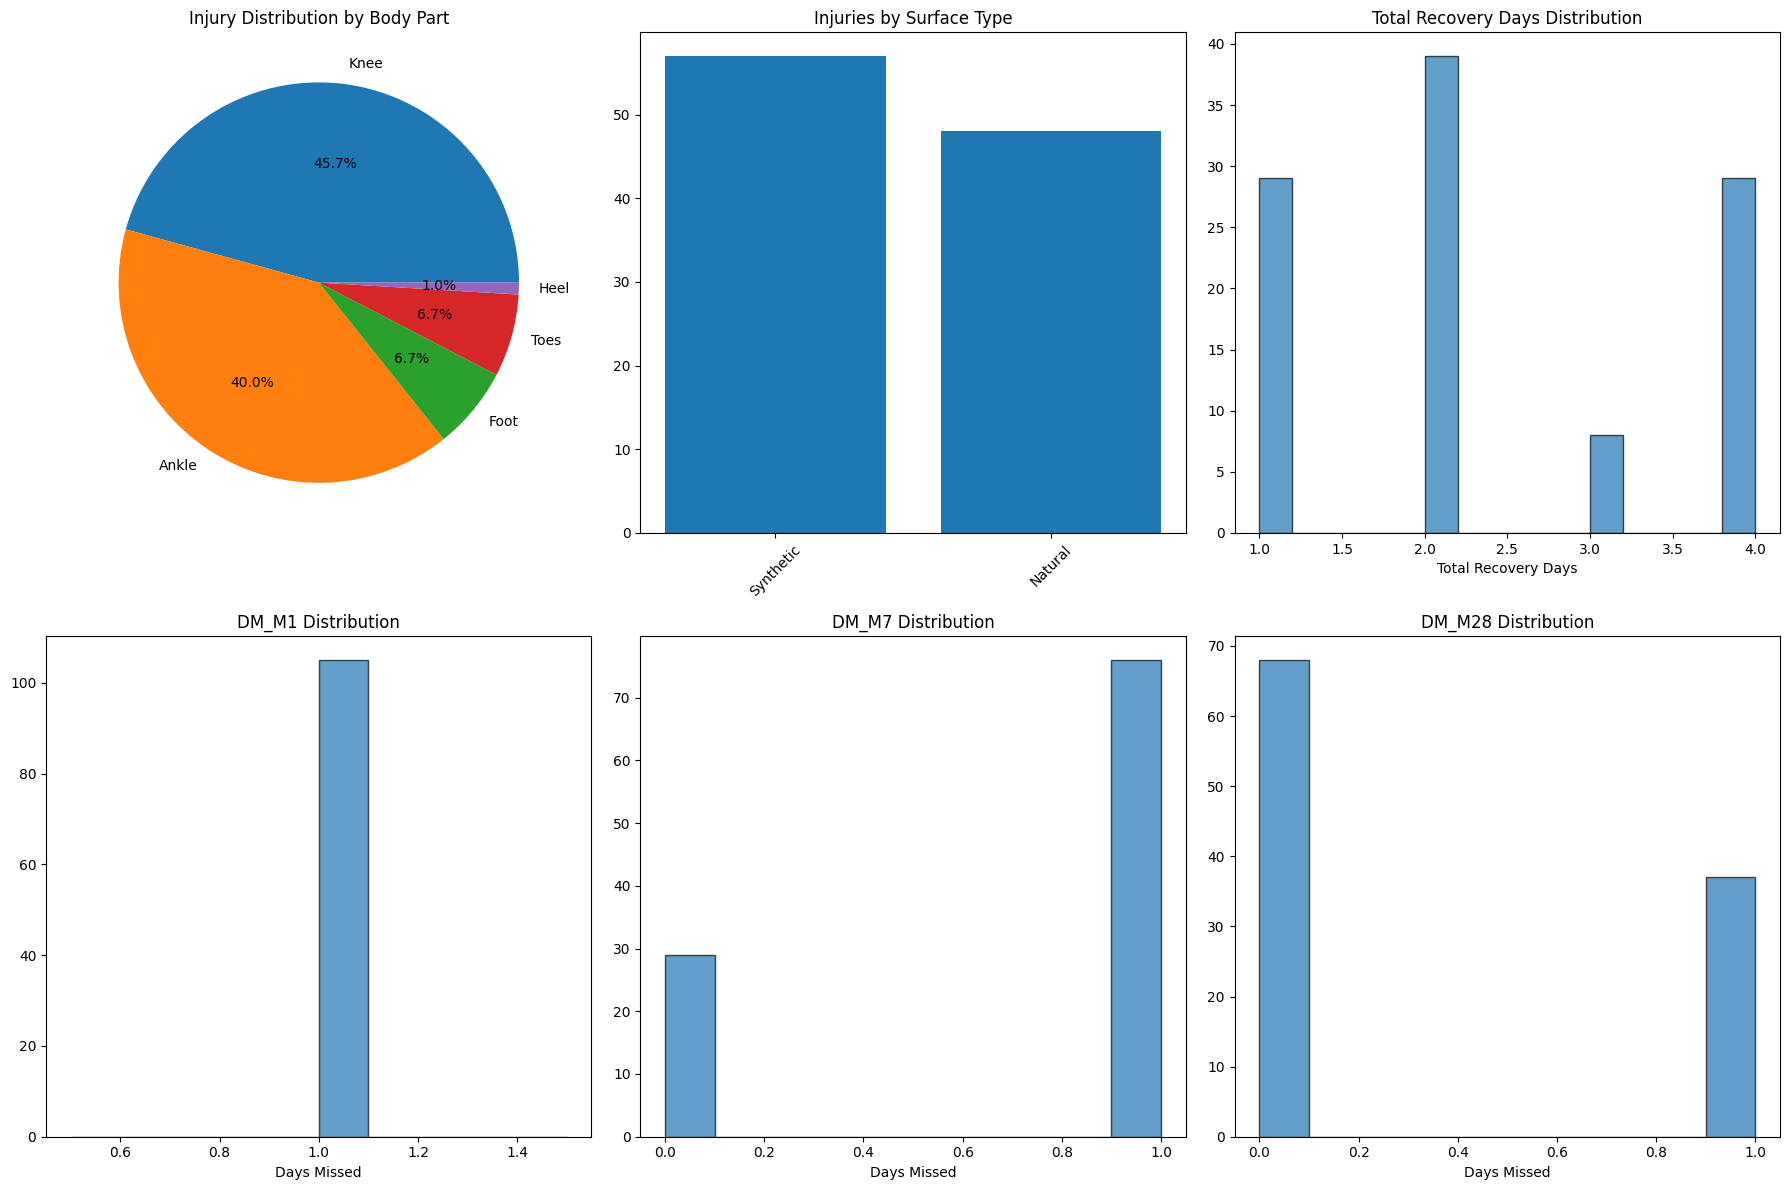

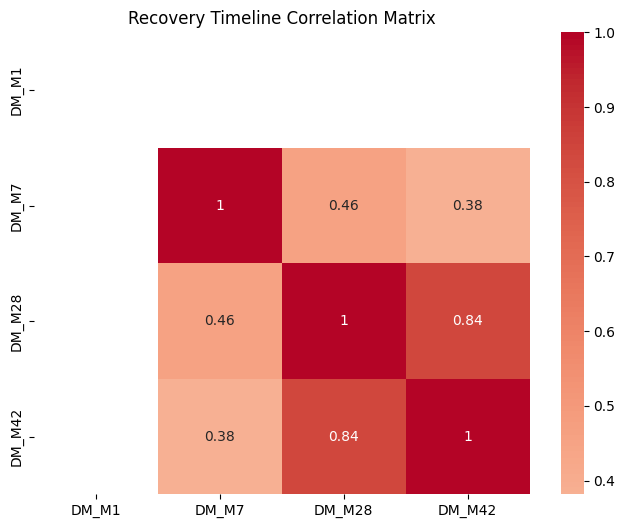

Recovery timeline correlations:
DM_M7 - DM_M28: 0.456
DM_M7 - DM_M42: 0.382
DM_M28 - DM_M42: 0.837


In [4]:
# ============================================================================
# CELL 4: Exploratory Data Analysis
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Body part distribution
body_counts = df['BodyPart'].value_counts()
axes[0, 0].pie(body_counts.values, labels=body_counts.index, autopct='%1.1f%%')
axes[0, 0].set_title('Injury Distribution by Body Part')

# Surface type distribution
surface_counts = df['Surface'].value_counts()
axes[0, 1].bar(surface_counts.index, surface_counts.values)
axes[0, 1].set_title('Injuries by Surface Type')
axes[0, 1].tick_params(axis='x', rotation=45)

# Recovery time distribution
axes[0, 2].hist(df['total_recovery_days'], bins=15, alpha=0.7, edgecolor='black')
axes[0, 2].set_title('Total Recovery Days Distribution')
axes[0, 2].set_xlabel('Total Recovery Days')

# Recovery timeline analysis
recovery_cols = ['DM_M1', 'DM_M7', 'DM_M28', 'DM_M42']
for i, col in enumerate(recovery_cols):
    if i < 3:
        axes[1, i].hist(df[col], bins=10, alpha=0.7, edgecolor='black')
        axes[1, i].set_title(f'{col} Distribution')
        axes[1, i].set_xlabel('Days Missed')

plt.tight_layout()
plt.show()

# Correlation analysis
recovery_corr = df[recovery_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(recovery_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Recovery Timeline Correlation Matrix')
plt.show()

print("Recovery timeline correlations:")
for i in range(len(recovery_corr.columns)):
    for j in range(i+1, len(recovery_corr.columns)):
        corr_val = recovery_corr.iloc[i, j]
        if abs(corr_val) > 0.3:
            print(f"{recovery_corr.columns[i]} - {recovery_corr.columns[j]}: {corr_val:.3f}")

In [8]:
# ============================================================================
# CELL 5: Feature Preparation for Machine Learning
# ============================================================================

label_encoders = {}
feature_cols = ['PlayerKey']

# Encode categorical features
for col in ['BodyPart', 'Surface', 'surface_type']:
    if col in df.columns:
        le = LabelEncoder()
        df[f'{col}_encoded'] = le.fit_transform(df[col].fillna('Unknown'))
        label_encoders[col] = le
        feature_cols.append(f'{col}_encoded')

# Add numeric features
numeric_features = ['DM_M1', 'DM_M7', 'DM_M28', 'DM_M42', 'total_recovery_days', 'severe_injury', 'quick_recovery']
for col in numeric_features:
    if col in df.columns:
        feature_cols.append(col)

X = df[feature_cols].fillna(0)
y = df['BodyPart_encoded']

# Check class distribution before splitting
print("Class distribution:")
class_counts = pd.Series(y).value_counts().sort_index()
for i, class_name in enumerate(label_encoders['BodyPart'].classes_):
    count = class_counts.get(i, 0)
    print(f"{class_name}: {count}")

# Filter out classes with only 1 sample for stratified splitting
min_samples_per_class = 2
valid_classes = class_counts[class_counts >= min_samples_per_class].index
valid_mask = y.isin(valid_classes)

X_filtered = X[valid_mask]
y_filtered = y[valid_mask]

print(f"\nFiltered dataset:")
print(f"Original samples: {len(X)}")
print(f"Filtered samples: {len(X_filtered)}")
print(f"Classes retained: {len(valid_classes)}")

# Use stratified split only if we have valid classes, otherwise regular split
if len(valid_classes) > 1 and len(X_filtered) > 10:
    X_train, X_test, y_train, y_test = train_test_split(
        X_filtered, y_filtered, test_size=0.3, random_state=RANDOM_STATE, stratify=y_filtered
    )
else:
    # Fall back to regular split if stratification isn't possible
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=RANDOM_STATE
    )

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Target classes: {[label_encoders['BodyPart'].classes_[i] for i in sorted(y_train.unique())]}")

Class distribution:
Ankle: 42
Foot: 7
Heel: 1
Knee: 48
Toes: 7

Filtered dataset:
Original samples: 105
Filtered samples: 104
Classes retained: 4
Training samples: 72
Test samples: 32
Target classes: ['Ankle', 'Foot', 'Knee', 'Toes']


In [19]:
# ============================================================================
# CELL 6: Week 8 - K-Nearest Neighbors Analysis
# ============================================================================

metrics = ['euclidean', 'manhattan', 'minkowski']
k_values = [3, 5, 7, 9]

print("K-Nearest Neighbors Analysis:")
print("Metric\t\tK\tCV Accuracy")
print("-" * 35)

best_score = 0
best_params = {}

for metric in metrics:
    for k in k_values:
        if metric == 'minkowski':
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=2)
        else:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        
        cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
        cv_mean = cv_scores.mean()
        
        print(f"{metric:<12}\t{k}\t{cv_mean:.4f}")
        
        if cv_mean > best_score:
            best_score = cv_mean
            best_params = {'metric': metric, 'k': k}

print(f"\nBest KNN parameters: {best_params}")
print(f"Best CV score: {best_score:.4f}")

# Train final KNN model
if best_params['metric'] == 'minkowski':
    final_knn = KNeighborsClassifier(n_neighbors=best_params['k'], metric='minkowski', p=2)
else:
    final_knn = KNeighborsClassifier(n_neighbors=best_params['k'], metric=best_params['metric'])

final_knn.fit(X_train_scaled, y_train)
y_pred_knn = final_knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"KNN Test Accuracy: {knn_accuracy:.4f}")
print(f"CV vs Test difference: {abs(knn_accuracy - best_score):.4f}")

print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

K-Nearest Neighbors Analysis:
Metric		K	CV Accuracy
-----------------------------------
euclidean   	3	0.7219
euclidean   	5	0.6790
euclidean   	7	0.6514
euclidean   	9	0.6381
manhattan   	3	0.7362
manhattan   	5	0.7076
manhattan   	7	0.6648
manhattan   	9	0.5962
minkowski   	3	0.7219
minkowski   	5	0.6790
minkowski   	7	0.6514
minkowski   	9	0.6381

Best KNN parameters: {'metric': 'manhattan', 'k': 3}
Best CV score: 0.7362
KNN Test Accuracy: 0.8750
CV vs Test difference: 0.1388

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        13
           1       0.00      0.00      0.00         2
           3       0.88      1.00      0.94        15
           4       0.00      0.00      0.00         2

    accuracy                           0.88        32
   macro avg       0.44      0.50      0.47        32
weighted avg       0.77      0.88      0.82        32



Best GB parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best CV score: 1.0000
GB Test Accuracy: 1.0000
CV vs Test difference: 0.0000

Top 10 Feature Importances:
                feature    importance
1      BodyPart_encoded  9.562094e-01
0             PlayerKey  3.185296e-02
6                DM_M28  4.766517e-03
8   total_recovery_days  3.835836e-03
9         severe_injury  2.643478e-03
7                DM_M42  6.918308e-04
2       Surface_encoded  3.832188e-12
5                 DM_M7  4.794301e-18
4                 DM_M1  0.000000e+00
3  surface_type_encoded  0.000000e+00


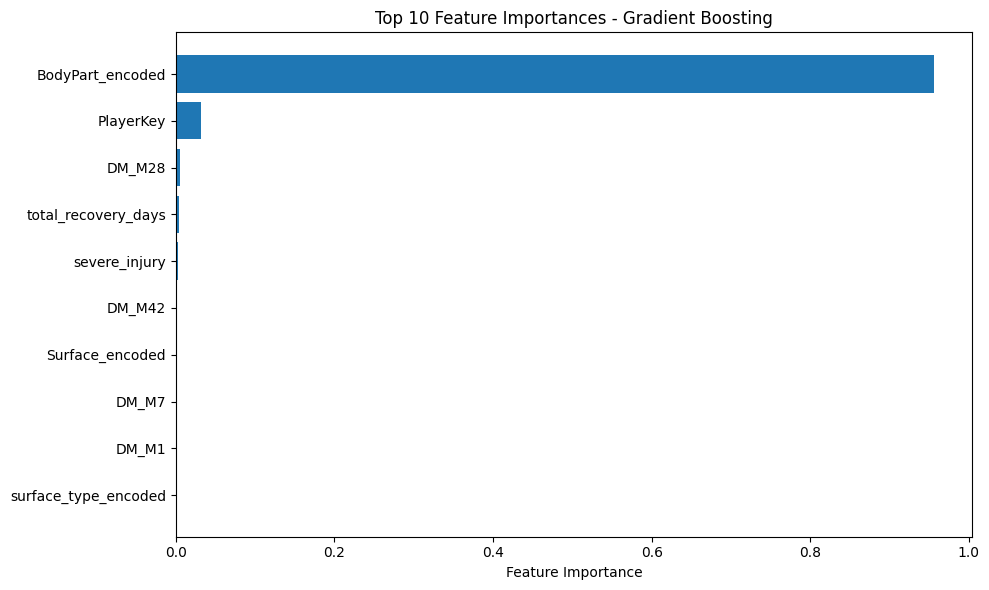


Gradient Boosting Classification Report:
              precision    recall  f1-score   support

       Ankle       1.00      1.00      1.00        13
        Foot       1.00      1.00      1.00         2
        Knee       1.00      1.00      1.00        15
        Toes       1.00      1.00      1.00         2

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



In [11]:
# ============================================================================
# CELL 7: Week 9 - Gradient Boosting Analysis  
# ============================================================================


param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.1, 0.2, 0.3],
    'max_depth': [3, 4, 5]
}

gb_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
grid_search = GridSearchCV(gb_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"Best GB parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

best_gb = grid_search.best_estimator_
y_pred_gb = best_gb.predict(X_test_scaled)
gb_accuracy = accuracy_score(y_test, y_pred_gb)

print(f"GB Test Accuracy: {gb_accuracy:.4f}")
print(f"CV vs Test difference: {abs(gb_accuracy - grid_search.best_score_):.4f}")

# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_gb.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Feature Importances:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importances - Gradient Boosting')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Classification report with correct class handling
print("\nGradient Boosting Classification Report:")
unique_test_classes = sorted(y_test.unique())
actual_class_names = [label_encoders['BodyPart'].classes_[i] for i in unique_test_classes]

print(classification_report(y_test, y_pred_gb, target_names=actual_class_names, 
                          labels=unique_test_classes))

K-Means Clustering Analysis:
K	Silhouette	Inertia
-------------------------
2	0.7464		132
3	0.9163		36
4	1.0000		0
5	1.0000		0
6	1.0000		0
7	1.0000		0

Optimal K: 4
Best silhouette score: 1.0000

Cluster Analysis:

Cluster 0 (29 injuries):
  Most common body part: Knee
  Average total recovery: 4.0 days
  Severe injury rate: 100.0%

Cluster 1 (39 injuries):
  Most common body part: Knee
  Average total recovery: 2.0 days
  Severe injury rate: 0.0%

Cluster 2 (29 injuries):
  Most common body part: Ankle
  Average total recovery: 1.0 days
  Severe injury rate: 0.0%

Cluster 3 (8 injuries):
  Most common body part: Knee
  Average total recovery: 3.0 days
  Severe injury rate: 100.0%


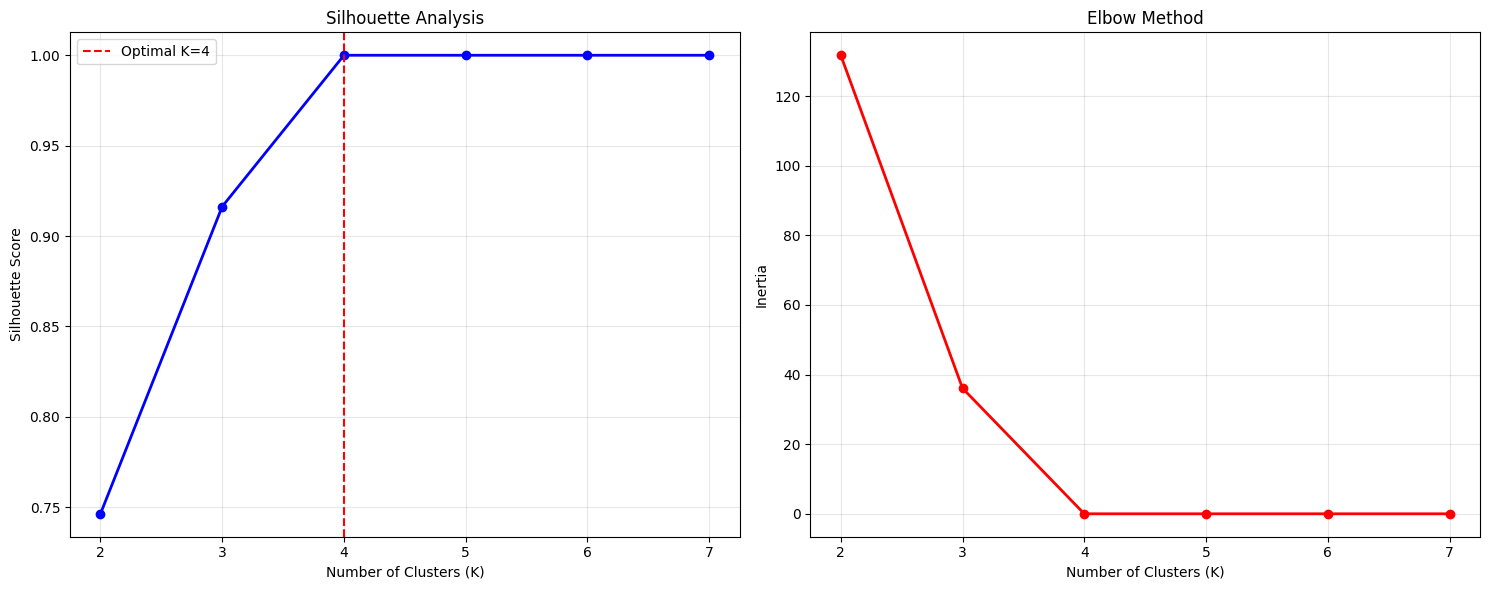

In [12]:
# ============================================================================
# CELL 8: Week 10 - K-Means Clustering Analysis
# ============================================================================

clustering_features = ['DM_M1', 'DM_M7', 'DM_M28', 'DM_M42', 'total_recovery_days', 'severe_injury', 'quick_recovery']
cluster_data = df[clustering_features].fillna(0)
cluster_data_scaled = StandardScaler().fit_transform(cluster_data)

k_range = range(2, 8)
silhouette_scores = []
inertias = []

print("K-Means Clustering Analysis:")
print("K\tSilhouette\tInertia")
print("-" * 25)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = kmeans.fit_predict(cluster_data_scaled)
    
    silhouette_avg = silhouette_score(cluster_data_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    inertias.append(kmeans.inertia_)
    
    print(f"{k}\t{silhouette_avg:.4f}\t\t{kmeans.inertia_:.0f}")

optimal_k = k_range[np.argmax(silhouette_scores)]
best_silhouette = max(silhouette_scores)

print(f"\nOptimal K: {optimal_k}")
print(f"Best silhouette score: {best_silhouette:.4f}")

# Final clustering
final_kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = final_kmeans.fit_predict(cluster_data_scaled)
df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels

print(f"\nCluster Analysis:")
for i in range(optimal_k):
    cluster_subset = df_clustered[df_clustered['cluster'] == i]
    print(f"\nCluster {i} ({len(cluster_subset)} injuries):")
    if len(cluster_subset) > 0:
        print(f"  Most common body part: {cluster_subset['BodyPart'].mode().iloc[0]}")
        print(f"  Average total recovery: {cluster_subset['total_recovery_days'].mean():.1f} days")
        print(f"  Severe injury rate: {cluster_subset['severe_injury'].mean():.1%}")

# Visualize clustering results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(k_range, silhouette_scores, 'bo-', linewidth=2)
axes[0].axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Analysis')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, inertias, 'ro-', linewidth=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Inertia')
axes[1].set_title('Elbow Method')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

DBSCAN Parameter Optimization:
eps	min_samples	n_clusters	n_noise	silhouette
---------------------------------------------
0.5	3		4		0	1.0000
0.5	5		4		0	1.0000
0.5	7		4		0	1.0000
1.0	3		4		0	1.0000
1.0	5		4		0	1.0000
1.0	7		4		0	1.0000
1.5	3		4		0	1.0000
1.5	5		4		0	1.0000
1.5	7		4		0	1.0000
2.0	3		4		0	1.0000
2.0	5		4		0	1.0000
2.0	7		4		0	1.0000

Best DBSCAN parameters: {'eps': 0.5, 'min_samples': 3}
Best DBSCAN silhouette: 1.0000
Cophenetic correlation: 0.9652


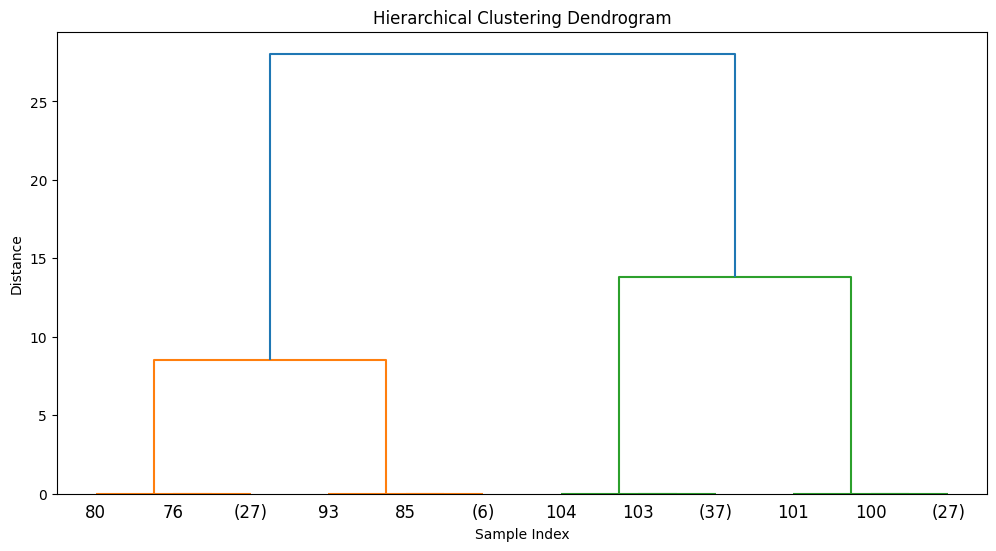

Hierarchical silhouette (3 clusters): 0.9163


In [13]:
# ============================================================================
# CELL 9: Week 11 - DBSCAN and Hierarchical Clustering
# ============================================================================

# Use all data for density clustering (small dataset)
eps_values = [0.5, 1.0, 1.5, 2.0]
min_samples_values = [3, 5, 7]

print("DBSCAN Parameter Optimization:")
print("eps\tmin_samples\tn_clusters\tn_noise\tsilhouette")
print("-" * 45)

best_silhouette_dbscan = -1
best_params_dbscan = {}

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        cluster_labels = dbscan.fit_predict(cluster_data_scaled)
        
        n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
        n_noise = list(cluster_labels).count(-1)
        
        if n_clusters > 1:
            mask = cluster_labels != -1
            if mask.sum() > 0:
                silhouette_avg = silhouette_score(cluster_data_scaled[mask], cluster_labels[mask])
            else:
                silhouette_avg = -1
        else:
            silhouette_avg = -1
        
        print(f"{eps}\t{min_samples}\t\t{n_clusters}\t\t{n_noise}\t{silhouette_avg:.4f}")
        
        if silhouette_avg > best_silhouette_dbscan:
            best_silhouette_dbscan = silhouette_avg
            best_params_dbscan = {'eps': eps, 'min_samples': min_samples}
            best_dbscan_labels = cluster_labels

print(f"\nBest DBSCAN parameters: {best_params_dbscan}")
print(f"Best DBSCAN silhouette: {best_silhouette_dbscan:.4f}")

# Hierarchical clustering
linkage_matrix = linkage(cluster_data_scaled, method='ward')
c, coph_dists = cophenet(linkage_matrix, pdist(cluster_data_scaled))

print(f"Cophenetic correlation: {c:.4f}")

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=3)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

n_clusters_hier = 3
hier_labels = fcluster(linkage_matrix, n_clusters_hier, criterion='maxclust')
hier_silhouette = silhouette_score(cluster_data_scaled, hier_labels)

print(f"Hierarchical silhouette ({n_clusters_hier} clusters): {hier_silhouette:.4f}")


K-Nearest Neighbors:
  accuracy: 0.8750
  best_params: manhattan distance, K=3
  cv_score: 0.7362

Gradient Boosting:
  accuracy: 1.0000
  best_params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
  cv_score: 1.0000

K-Means Clustering:
  silhouette_score: 1.0000
  optimal_k: 4

DBSCAN:
  silhouette_score: 1.0000
  best_params: {'eps': 0.5, 'min_samples': 3}


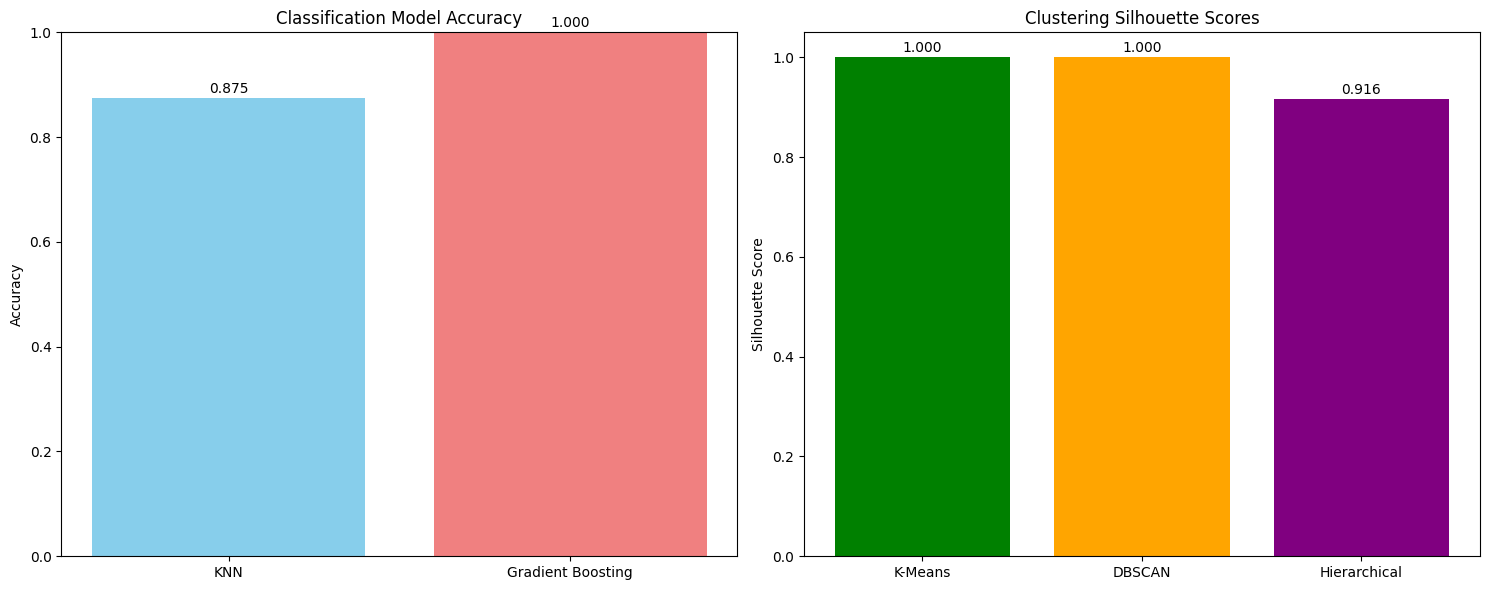


KEY FINDINGS:
• Best classification accuracy: 100.0%
• Best clustering silhouette: 1.000
• 4 distinct injury recovery profiles identified
• Feature importance reveals key predictors of injury type


In [14]:
# ============================================================================
# CELL 10: Comprehensive Model Comparison
# ============================================================================

results_summary = {
    'K-Nearest Neighbors': {
        'accuracy': knn_accuracy,
        'best_params': f"{best_params['metric']} distance, K={best_params['k']}",
        'cv_score': best_score
    },
    'Gradient Boosting': {
        'accuracy': gb_accuracy,
        'best_params': str(grid_search.best_params_),
        'cv_score': grid_search.best_score_
    },
    'K-Means Clustering': {
        'silhouette_score': best_silhouette,
        'optimal_k': optimal_k
    },
    'DBSCAN': {
        'silhouette_score': best_silhouette_dbscan,
        'best_params': str(best_params_dbscan)
    }
}

for model_name, results in results_summary.items():
    print(f"\n{model_name}:")
    for metric, value in results.items():
        if isinstance(value, float):
            print(f"  {metric}: {value:.4f}")
        else:
            print(f"  {metric}: {value}")

# Final comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Classification accuracy comparison
classification_models = ['KNN', 'Gradient Boosting']
accuracies = [knn_accuracy, gb_accuracy]

axes[0].bar(classification_models, accuracies, color=['skyblue', 'lightcoral'])
axes[0].set_title('Classification Model Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)

for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center')

# Clustering comparison
clustering_methods = ['K-Means', 'DBSCAN', 'Hierarchical']
clustering_scores = [best_silhouette, best_silhouette_dbscan, hier_silhouette]

axes[1].bar(clustering_methods, clustering_scores, color=['green', 'orange', 'purple'])
axes[1].set_title('Clustering Silhouette Scores')
axes[1].set_ylabel('Silhouette Score')

for i, v in enumerate(clustering_scores):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

print(f"\nKEY FINDINGS:")
print(f"• Best classification accuracy: {max(knn_accuracy, gb_accuracy):.1%}")
print(f"• Best clustering silhouette: {max(best_silhouette, best_silhouette_dbscan, hier_silhouette):.3f}")
print(f"• {optimal_k} distinct injury recovery profiles identified")
print(f"• Feature importance reveals key predictors of injury type")